In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [57]:
df=sns.load_dataset('iris')

In [58]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [59]:
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

df = pd.read_csv('pima-indians-diabetes.csv', names=columns)



In [60]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [61]:
duplicates = df.duplicated()
print("Số dòng trùng lặp:", duplicates.sum())

df_cleaned = df.drop_duplicates()
print("Số dòng sau khi loại bỏ trùng lặp:", df_cleaned.shape)

Số dòng trùng lặp: 0
Số dòng sau khi loại bỏ trùng lặp: (768, 9)


In [62]:
physiological_ranges = {
    'Pregnancies': (0, 20),
    'Glucose': (40, 200),
    'BloodPressure': (20, 140),
    'SkinThickness': (5, 99),
    'Insulin': (15, 846),
    'BMI': (15, 60),
    'DiabetesPedigreeFunction': (0.0, 2.5),
    'Age': (10, 100)
}

In [63]:
def detect_physiological_errors(df, physiological_ranges):
    if not isinstance(df, pd.DataFrame):
        raise TypeError('df must be a pandas DataFrame')
    if not isinstance(physiological_ranges, dict):
        raise TypeError('physiological_ranges must be a dict')
    errors = {}
    for col, valid_range in physiological_ranges.items():
        if col not in df.columns:
            continue
        if not (isinstance(valid_range, (tuple, list)) and len(valid_range) == 2):
            raise ValueError(f'Range for {col} must be tuple/list (min, max)')
        min_val, max_val = valid_range
        col_values = df[col]
        invalid_mask = col_values.notna() & ((col_values < min_val) | (col_values > max_val))
        invalid_values = col_values[invalid_mask]
        if not invalid_values.empty:
            errors[col] = {
                'count': int(invalid_values.shape[0]),
                'min_actual': float(col_values.min()) if pd.notna(col_values.min()) else None,
                'max_actual': float(col_values.max()) if pd.notna(col_values.max()) else None,
                'problem_values': sorted(set(invalid_values.tolist()))
            }
    return errors

In [64]:
errors = detect_physiological_errors(df, physiological_ranges)
print("=== Dữ liệu lỗi phát hiện ===")
for col, info in errors.items():
        print(f"{col}: {info['count']} giá trị lỗi")
        print(f" -Range thực tế: {info['min_actual']} - {info['max_actual']}")
        print(f" -Giá trị có vấn đề: {info['problem_values']}")

=== Dữ liệu lỗi phát hiện ===
Glucose: 5 giá trị lỗi
 -Range thực tế: 0.0 - 199.0
 -Giá trị có vấn đề: [0]
BloodPressure: 35 giá trị lỗi
 -Range thực tế: 0.0 - 122.0
 -Giá trị có vấn đề: [0]
SkinThickness: 227 giá trị lỗi
 -Range thực tế: 0.0 - 99.0
 -Giá trị có vấn đề: [0]
Insulin: 375 giá trị lỗi
 -Range thực tế: 0.0 - 846.0
 -Giá trị có vấn đề: [0, 14]
BMI: 12 giá trị lỗi
 -Range thực tế: 0.0 - 67.1
 -Giá trị có vấn đề: [0.0, 67.1]


In [65]:

def handle_zero_values(df):
    zero_sensitive_columns = ['Insulin', 'SkinThickness']
    for col in zero_sensitive_columns:
        zero_mask = df[col] == 0
        if zero_mask.any():
            print(f"Phát hiện {zero_mask.sum()} giá trị 0 trong {col}")
            median_val = df[col][df[col] > 0].median()
            df.loc[zero_mask, col] = median_val
            print(f" -> Đã thay thế bằng median: {median_val:.2f}")
    return df
df_final = handle_zero_values(df_cleaned)

Phát hiện 374 giá trị 0 trong Insulin
 -> Đã thay thế bằng median: 125.00
Phát hiện 227 giá trị 0 trong SkinThickness
 -> Đã thay thế bằng median: 29.00


In [66]:
print("=== KẾT QUẢ SAU XỬ LÝ ===")
print(f"Dữ liệu gốc: {len(df)} dòng")
print(f"Sau xử lý: {len(df_final)} dòng")
print(f"Tỷ lệ giữ lại: {len(df_final)/len(df)*100:.1f}%")
final_errors = detect_physiological_errors(df_final, physiological_ranges)
if not final_errors:
    print("Tất cả dữ liệu đều trong ngưỡng sinh lý hợp lý")
else:
    print("Vẫn còn dữ liệu lỗi:")
    for col, info in final_errors.items():
        print(f" - {col}: {info['count']} lỗi")

=== KẾT QUẢ SAU XỬ LÝ ===
Dữ liệu gốc: 768 dòng
Sau xử lý: 768 dòng
Tỷ lệ giữ lại: 100.0%
Vẫn còn dữ liệu lỗi:
 - Glucose: 5 lỗi
 - BloodPressure: 35 lỗi
 - Insulin: 1 lỗi
 - BMI: 12 lỗi


In [67]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


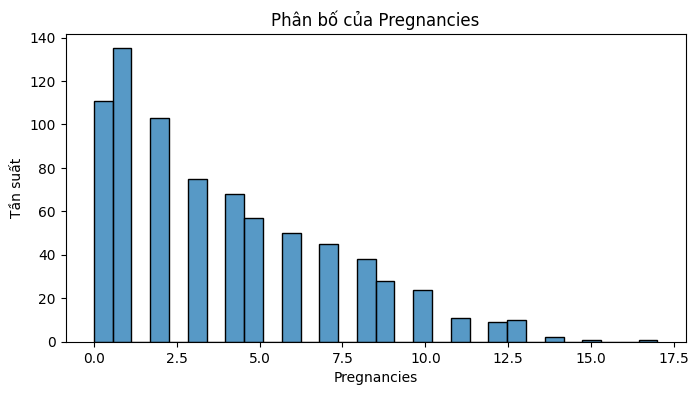

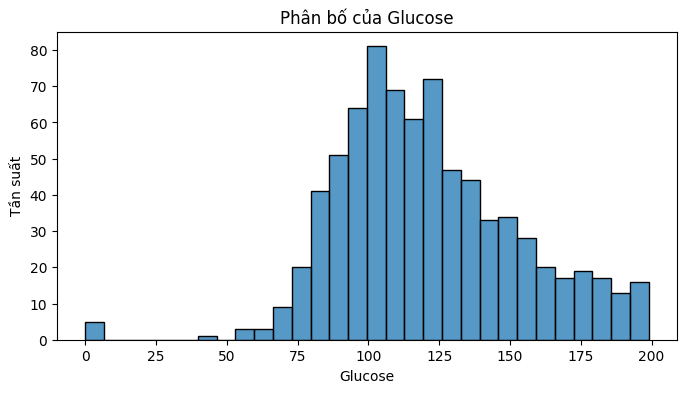

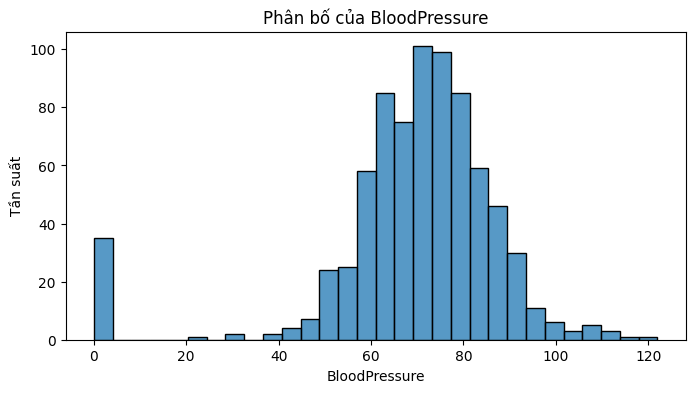

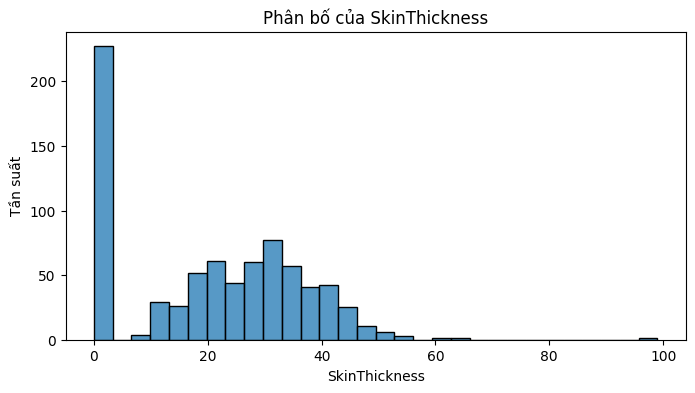

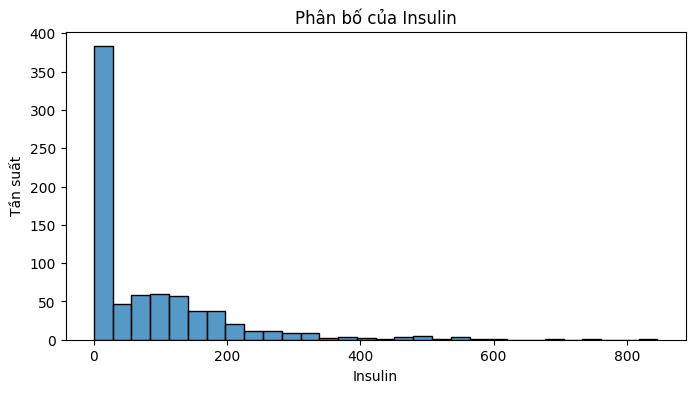

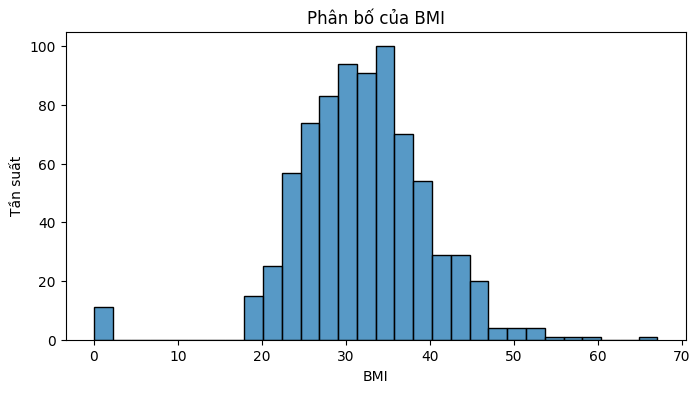

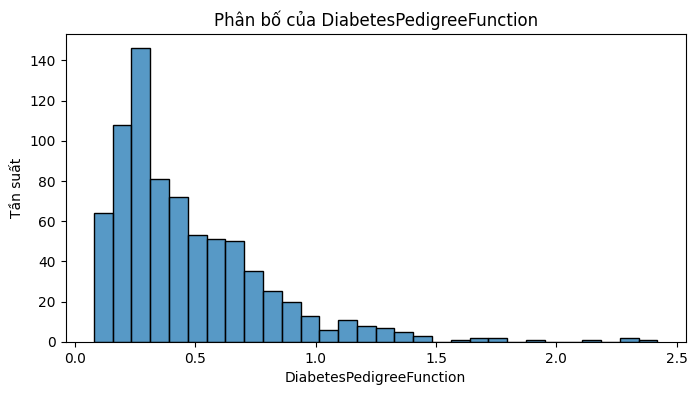

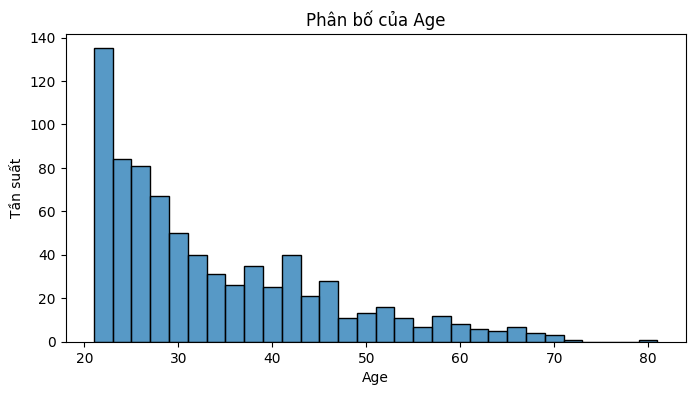

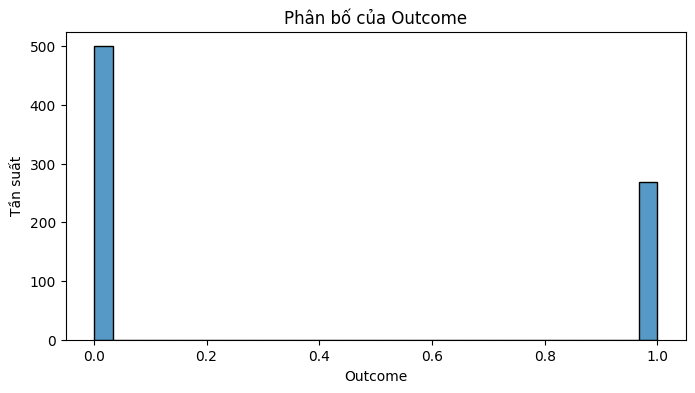

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns


for column in df.columns:
    plt.figure(figsize=(8, 4))
    if df[column].dtype in ['int64', 'float64']:
        sns.histplot(df[column], kde=False, bins=30)
        plt.title(f'Phân bố của {column}')
        plt.xlabel(column)
        plt.ylabel('Tần suất')
    else:
        sns.countplot(x=df[column])
        plt.title(f'Phân bố của {column}')
        plt.xlabel(column)
        plt.ylabel('Số lượng')
    plt.show()

=== PHÁT HIỆN OUTLIERS BẰNG IQR ===
Pregnancies: 4 outliers
  - Giới hạn dưới: -6.50, Giới hạn trên: 13.50
  - Giá trị outliers: [np.int64(14), np.int64(15), np.int64(17)]...

Glucose: 5 outliers
  - Giới hạn dưới: 37.12, Giới hạn trên: 202.12
  - Giá trị outliers: [np.int64(0)]...

BloodPressure: 45 outliers
  - Giới hạn dưới: 35.00, Giới hạn trên: 107.00
  - Giá trị outliers: [np.int64(0), np.int64(24), np.int64(30), np.int64(108), np.int64(110), np.int64(114), np.int64(122)]...

SkinThickness: 87 outliers
  - Giới hạn dưới: 14.50, Giới hạn trên: 42.50
  - Giá trị outliers: [np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(43), np.int64(44), np.int64(45)]...

Insulin: 346 outliers
  - Giới hạn dưới: 112.88, Giới hạn trên: 135.88
  - Giá trị outliers: [np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(22), np.int64(23), np.int64(25), np.int64(29), np.int64(32), np.int64(36)]...

BMI: 19 outliers
  - Giới hạn dưới: 

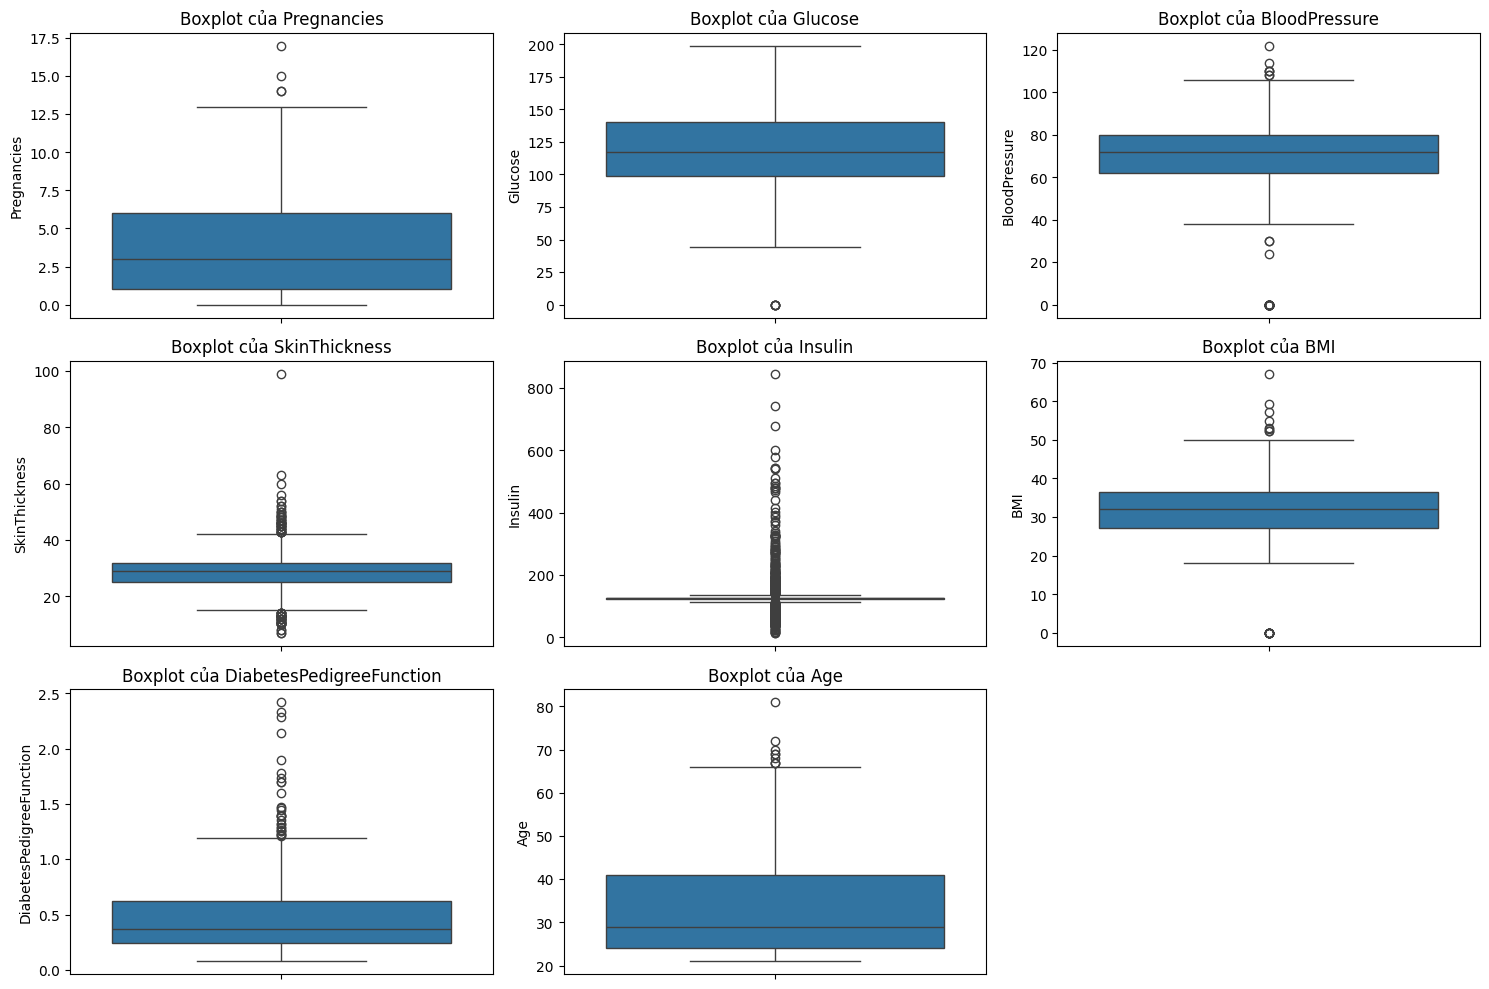

In [69]:
import numpy as np
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound
print("=== PHÁT HIỆN OUTLIERS BẰNG IQR ===")
numeric_columns = df_final.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if col != 'Outcome':  
        outliers, lower, upper = detect_outliers_iqr(df_final, col)
        print(f"{col}: {len(outliers)} outliers")
        if len(outliers) > 0:
            print(f"  - Giới hạn dưới: {lower:.2f}, Giới hạn trên: {upper:.2f}")
            print(f"  - Giá trị outliers: {sorted(outliers[col].unique())[:10]}...")  
        print()
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    if col != 'Outcome':
        plt.subplot(3, 3, i+1)
        sns.boxplot(y=df_final[col])
        plt.title(f'Boxplot của {col}')
plt.tight_layout()
plt.show()

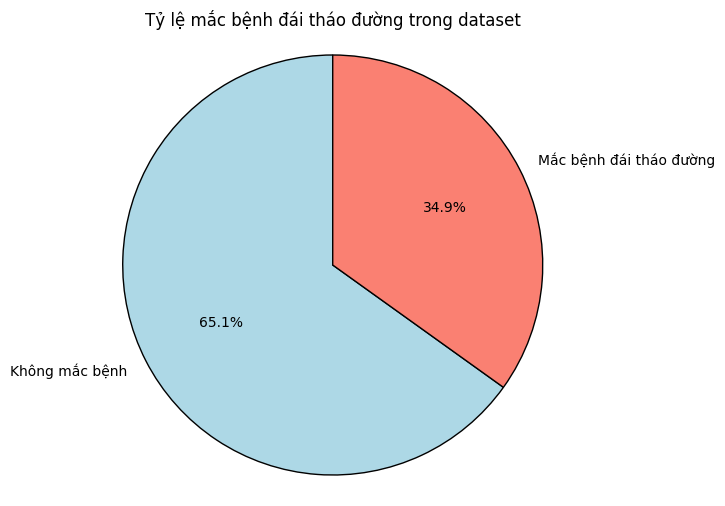

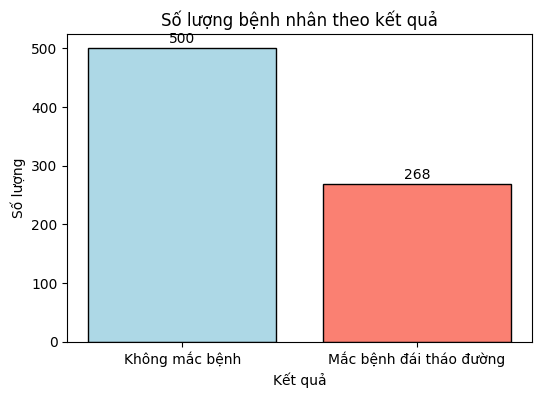

In [70]:
# Vẽ tỷ lệ mắc bệnh đái tháo đường
outcome_counts = df_final['Outcome'].value_counts()
labels = ['Không mắc bệnh', 'Mắc bệnh đái tháo đường']
colors = ['lightblue', 'salmon']

plt.figure(figsize=(8, 6))
plt.pie(outcome_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Tỷ lệ mắc bệnh đái tháo đường trong dataset')
plt.axis('equal')  # Đảm bảo hình tròn
plt.show()

# Thêm bar chart để so sánh
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, outcome_counts.values, color=colors, edgecolor='black')
plt.title('Số lượng bệnh nhân theo kết quả')
plt.ylabel('Số lượng')
plt.xlabel('Kết quả')
for bar, count in zip(bars, outcome_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', va='bottom')
plt.show()